# Set up

In [47]:
import numpy as np
import matplotlib.pyplot as plt

SEED = 0
np.random.seed(SEED)

SAMPLE_SIZE = 1000
EPOCHS = 100
LEARNING_RATE = 0.001

# Dataset

In [48]:
X = np.random.uniform(-1, 1, (SAMPLE_SIZE, 2))

W_TRUE = np.array([1, 1])
B_TRUE = 0

Y = np.sign(X @ W_TRUE + B_TRUE)

mask = Y != 0
X = X[mask]
Y = Y[mask]

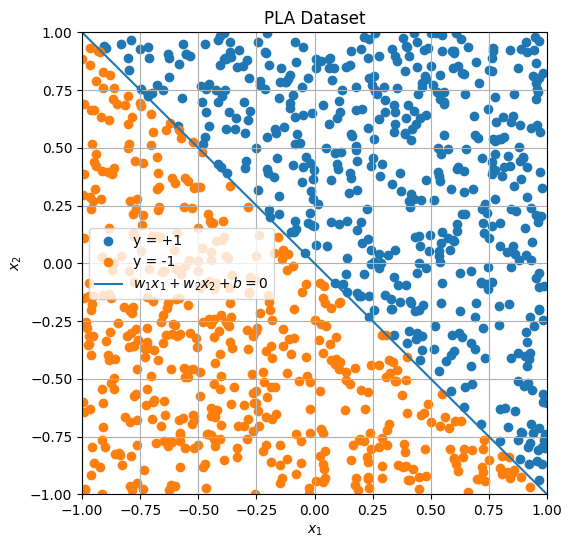

In [ ]:
def plot_dataset(x, y, w, b):
    pos = x[y == 1]
    neg = x[y == -1]

    # Plot
    plt.figure(figsize=(6, 6))

    plt.scatter(pos[:, 0], pos[:, 1], label="y = +1")

    plt.scatter(neg[:, 0], neg[:, 1], label="y = -1")

    # True decision boundary
    x1 = np.linspace(-1, 1, 200)
    x2 = -(w[0] * x1 + b) / w[1]

    plt.plot(
        x1,
        x2,
        label=r"$w_1 x_1 + w_2 x_2 + b = 0$",
    )

    plt.xlim(-1, 1)
    plt.ylim(-1, 1)

    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$")
    plt.title("PLA Dataset")
    plt.grid(True)
    plt.legend()
    plt.show()


plot_dataset(X, Y, W_TRUE, B_TRUE)

# PLA

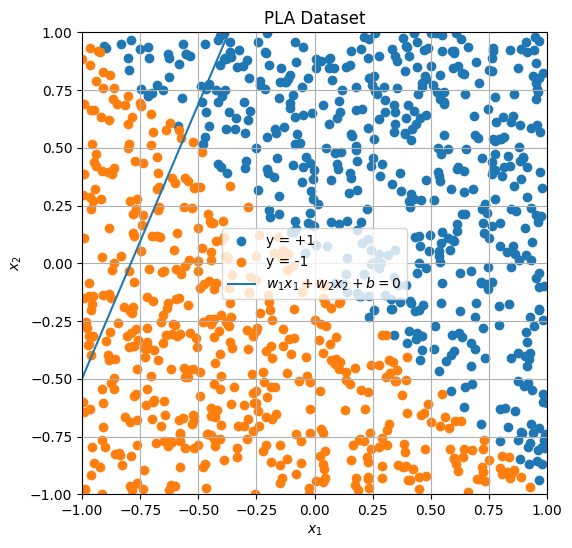

Epoch 0: w = [0.01434384 0.21683052], b = -0.008190382660329572 Average Error = 0.8340


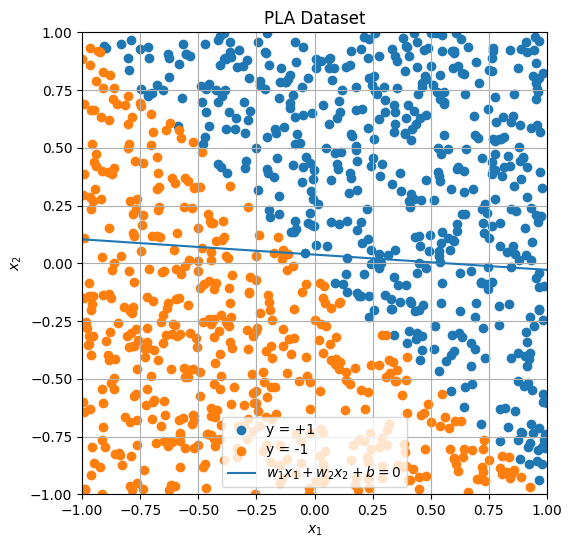

Early stopping at epoch 5 w = [0.13214995 0.13414069], b = -0.0021903826603295717 Average Error = 0.0060


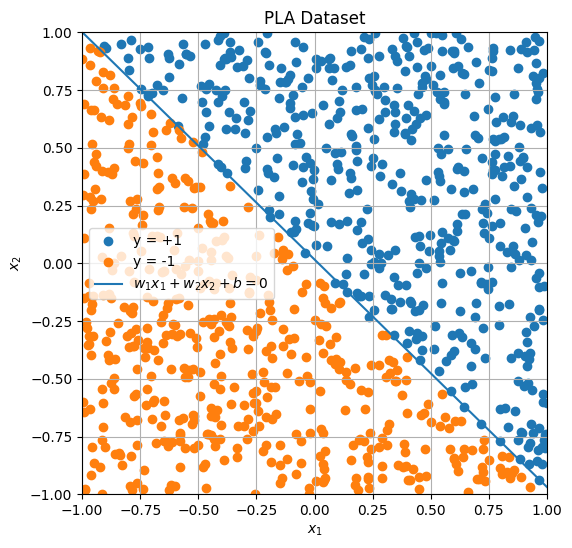

In [ ]:
def predict(x, w, b):
    return np.sign(x @ w + b)


def update(x, y, w, b, lr=LEARNING_RATE):
    y_pred = predict(x, w, b)
    error = y - y_pred
    w += lr * x.T @ error
    b += lr * np.sum(error)
    return w, b, error


def early_stopping(error, threshold=0.01):
    return np.mean(np.abs(error)) < threshold


w = np.random.uniform(-1, 1, 2)
b = np.random.uniform(-1, 1)

plot_dataset(X, Y, w, b)

for epoch in range(EPOCHS):
    total_error = 0
    for i in range(len(X)):
        w, b, error = update(X[i : i + 1], Y[i : i + 1], w, b)
        total_error += np.sum(np.abs(error))
    if epoch % 10 == 0:
        print(
            f"Epoch {epoch}: w = {w}, b = {b}",
            f"Average Error = {total_error / len(X):.4f}",
        )
        plot_dataset(X, Y, w, b)
    if early_stopping(total_error / len(X)):
        print(
            f"Early stopping at epoch {epoch}",
            f"w = {w}, b = {b}",
            f"Average Error = {total_error / len(X):.4f}",
        )
        break

plot_dataset(X, Y, w, b)